Cross-dataset summary plot

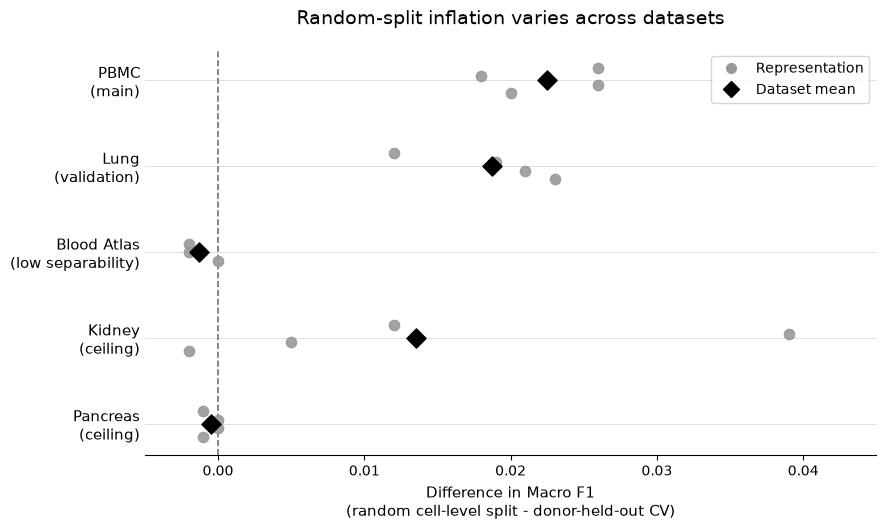

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Data
# ============================================================

data = [
    ("PBMC", "HVG",     0.787, 0.767),
    ("PBMC", "PCA",     0.808, 0.782),
    ("PBMC", "Harmony", 0.767, 0.749),
    ("PBMC", "scVI",    0.770, 0.744),

    ("Lung", "HVG",     0.878, 0.855),
    ("Lung", "PCA",     0.811, 0.790),
    ("Lung", "Harmony", 0.728, 0.709),
    ("Lung", "scVI",    0.886, 0.874),

    ("Blood Atlas", "HVG",     0.259, 0.259),
    ("Blood Atlas", "PCA",     0.235, 0.237),
    ("Blood Atlas", "Harmony", 0.235, 0.237),

    ("Kidney", "HVG",     0.976, 0.978),
    ("Kidney", "PCA",     0.979, 0.974),
    ("Kidney", "Harmony", 0.938, 0.899),
    ("Kidney", "scVI",    0.978, 0.966),

    ("Pancreas", "HVG",     0.995, 0.996),
    ("Pancreas", "PCA",     0.992, 0.992),
    ("Pancreas", "Harmony", 0.992, 0.992),
    ("Pancreas", "scVI",    0.992, 0.993),
]

df = pd.DataFrame(
    data,
    columns=["Dataset", "Representation", "Random", "Donor_held_out"]
)

df["Inflation"] = df["Random"] - df["Donor_held_out"]

dataset_order = [
    "PBMC",
    "Lung",
    "Blood Atlas",
    "Kidney",
    "Pancreas",
]

dataset_labels = [
    "PBMC\n(main)",
    "Lung\n(validation)",
    "Blood Atlas\n(low separability)",
    "Kidney\n(ceiling)",
    "Pancreas\n(ceiling)",
]

means = (
    df.groupby("Dataset")["Inflation"]
      .mean()
      .reindex(dataset_order)
)

# top -> bottom
y_base = np.arange(len(dataset_order))[::-1]

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(9.5, 5.8))

# Individual representation values
for i, dataset in enumerate(dataset_order):
    vals = df.loc[df["Dataset"] == dataset, "Inflation"].to_numpy()

    if len(vals) == 4:
        offsets = np.array([-0.15, -0.05, 0.05, 0.15])
    elif len(vals) == 3:
        offsets = np.array([-0.10, 0.00, 0.10])
    else:
        offsets = np.linspace(-0.12, 0.12, len(vals))

    ax.scatter(
        vals,
        y_base[i] + offsets,
        s=55,
        color="0.60",
        alpha=0.9,
        zorder=3,
    )

# Dataset means
ax.scatter(
    means.values,
    y_base,
    marker="D",
    s=95,
    color="black",
    zorder=4,
)

# Zero reference line
ax.axvline(
    0,
    linestyle="--",
    linewidth=1.2,
    color="0.45",
    zorder=1,
)

# Horizontal guides
for y in y_base:
    ax.axhline(
        y,
        linewidth=0.7,
        color="0.88",
        zorder=0,
    )

# Labels
ax.set_yticks(y_base)
ax.set_yticklabels(dataset_labels, fontsize=11)

ax.set_xlabel(
    "Difference in Macro F1\n"
    "(random cell-level split - donor-held-out CV)",
    fontsize=11,
)

ax.set_title(
    "Random-split inflation varies across datasets",
    fontsize=14,
    pad=18,
)

# Legend with symbols
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=7,
        markerfacecolor='0.60',
        markeredgecolor='0.60',
        label='Representation'
    ),
    Line2D(
        [0], [0],
        marker='D',
        linestyle='None',
        markersize=8,
        markerfacecolor='black',
        markeredgecolor='black',
        label='Dataset mean'
    )
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    facecolor='white',
    edgecolor='0.8',
    fontsize=10
)

# Styling
ax.set_xlim(-0.005, 0.045)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

fig.subplots_adjust(
    left=0.20,
    right=0.97,
    bottom=0.17,
    top=0.87,
)

plt.show()